# Wildfire Risk Analysis in the United States (1992–2020)

### By Leah Morgenstern

To begin the analysis, we import several Python modules that enable data access, processing, and visualization. The sqlite3 library allows us to connect to the wildfire dataset stored in a SQLite database, while pandas is used for data manipulation and analysis. Additional libraries assist with creating visualizations that help identify patterns relevant to wildfire risk

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

Next, we establish a connection to the database so that the wildfire records can be accessed and queried throughout the analysis.

In [44]:
# create db connection
conn = sqlite3.connect("C:/Users/leahm/anaconda_3/Library/data.sqlite")

# pull the fires table into RAM
fires = pd.read_sql_query("SELECT * FROM Fires", conn)

# check size
print(fires.memory_usage(index=True).sum() / (1024**2), 'Mb')

# disconnect from db
conn.close()

685.4178657531738 Mb


Before beginning the analysis, we briefly inspect the dataset to understand its structure and available variables. Reviewing column names and sample records helps verify that the data has loaded correctly and informs how it will be used in subsequent analysis.

In [8]:
# glimpse at data
print(fires.head())

   OBJECTID                                              Shape  FOD_ID  \
0         1  b'\x00\x01\xad\x10\x00\x00\xc8\xce\n[_@^\xc0\x...       1   
1         2  b'\x00\x01\xad\x10\x00\x00\xc8\xe594\xe2\x19^\...       2   
2         3  b'\x00\x01\xad\x10\x00\x00x{\xac \x13/^\xc0@\x...       3   
3         4  b'\x00\x01\xad\x10\x00\x00\xc8\x13u\xd7s\xfa]\...       4   
4         5  b'\x00\x01\xad\x10\x00\x00\xd0\x11y\xf8\xb6\xf...       5   

       FPA_ID SOURCE_SYSTEM_TYPE SOURCE_SYSTEM NWCG_REPORTING_AGENCY  \
0  FS-1418826                FED   FS-FIRESTAT                    FS   
1  FS-1418827                FED   FS-FIRESTAT                    FS   
2  FS-1418835                FED   FS-FIRESTAT                    FS   
3  FS-1418845                FED   FS-FIRESTAT                    FS   
4  FS-1418847                FED   FS-FIRESTAT                    FS   

  NWCG_REPORTING_UNIT_ID  NWCG_REPORTING_UNIT_NAME SOURCE_REPORTING_UNIT  ...  \
0                USCAPNF    Plumas Nation

## Wildfires Over Time

Our first visualization examines the number of wildfires recorded annually in the United States between 1992 and 2020.

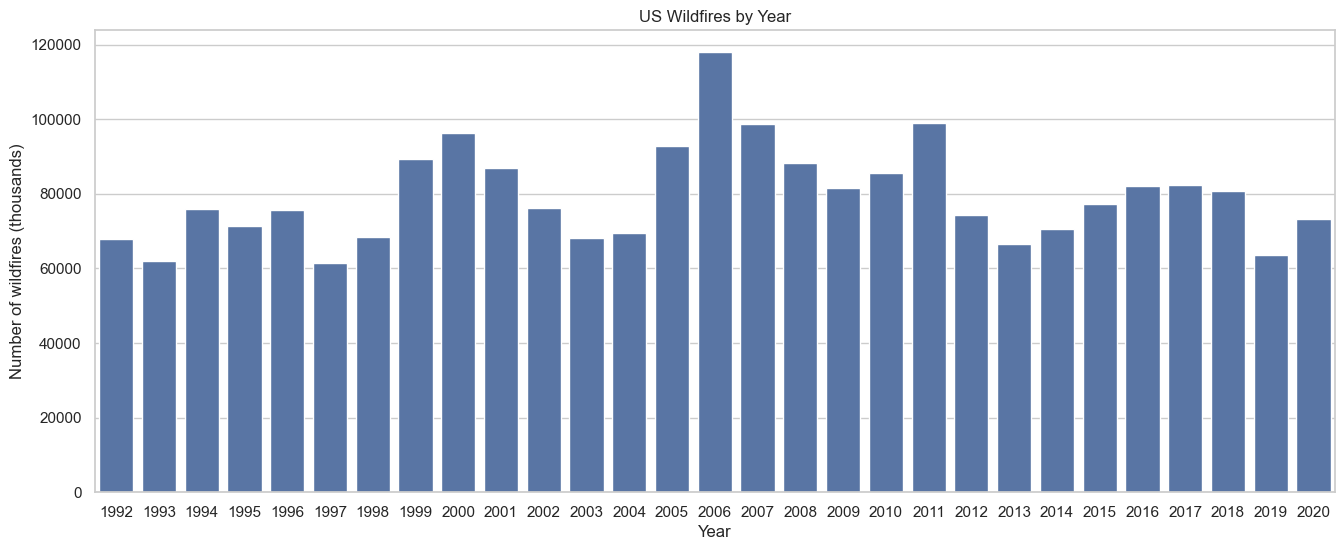

In [11]:
plt.figure(figsize=(16, 6))
sns.set(style="whitegrid")
sns.barplot(x="FIRE_YEAR", y="n_fires", data=fires.groupby('FIRE_YEAR').size().reset_index(name='n_fires'))
plt.xlabel('Year')
plt.ylabel('Number of wildfires (thousands)')
plt.title('US Wildfires by Year')
plt.show()

Annual wildfire counts generally range between approximately 60,000 and 100,000 fires per year, with a notable spike in 2006 approaching 120,000 fires.

From a risk perspective, this plot highlights the baseline frequency of wildfire events in the United States. While the number of fires fluctuates annually, the consistently high frequency indicates that wildfire represents a persistent natural hazard rather than an occasional anomaly. Periods of elevated fire activity may correspond with climatic factors such as drought conditions, temperature anomalies, or land management practices, all of which influence the likelihood of ignition and spread.

Understanding these temporal patterns is an important first step in wildfire risk assessment because frequency trends can influence preparedness planning, resource allocation, and insurance risk modeling.

## Causes of Wildfires

Next, we examine the reported causes of wildfires and the number of incidents attributed to each category.

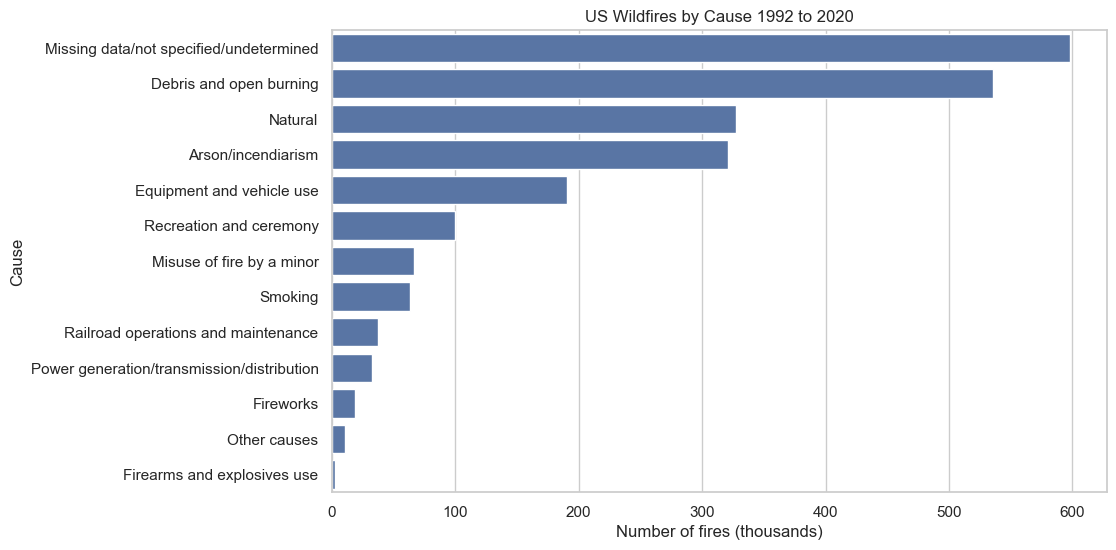

In [14]:
# Group by cause and calculate the number of fires
fires_cause = fires.groupby('NWCG_GENERAL_CAUSE').size().reset_index(name='n_fires')
fires_cause['n_fires'] /= 1000  # Convert to thousands

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.barplot(y="NWCG_GENERAL_CAUSE", x="n_fires", data=fires_cause.sort_values(by='n_fires', ascending=False))
plt.xlabel('Number of fires (thousands)')
plt.ylabel('Cause')
plt.title('US Wildfires by Cause 1992 to 2020')
plt.show()

The most common category in the dataset is “Missing data / Not specified / Undetermined.” This highlights an important limitation in the dataset: a large portion of wildfire ignitions do not have a confirmed cause.

From a risk analysis perspective, this uncertainty is significant. When ignition sources are poorly documented, it becomes more difficult to develop targeted mitigation strategies. For example, distinguishing between human-caused fires (e.g., equipment use, campfires, debris burning) and natural ignitions (e.g., lightning) is critical for determining whether prevention efforts should focus on behavioral interventions, policy changes, or environmental monitoring.

Despite this limitation, the dataset still provides valuable insights into general ignition patterns and their potential role in wildfire risk.

Next, we examine wildfire causes in relation to the total area burned rather than simply the number of fires.

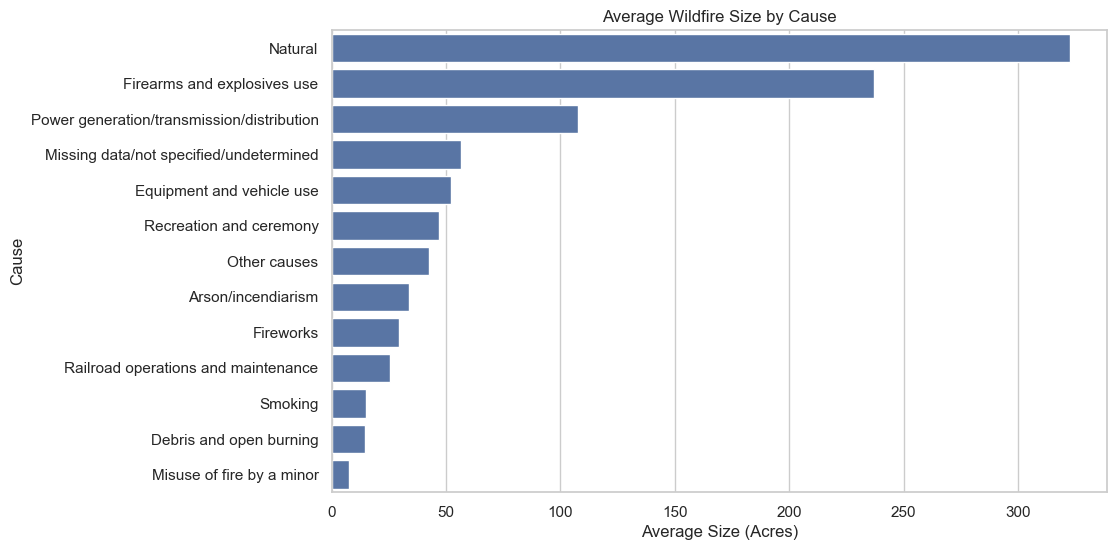

In [17]:
# Group by cause and calculate the mean size of fires
fires_cause_mean_size = fires.groupby('NWCG_GENERAL_CAUSE')['FIRE_SIZE'].mean().reset_index(name='mean_size')

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.barplot(y="NWCG_GENERAL_CAUSE", x="mean_size", data=fires_cause_mean_size.sort_values(by='mean_size', ascending=False))
plt.xlabel('Average Size (Acres)')
plt.ylabel('Cause')
plt.title('Average Wildfire Size by Cause')
plt.show()

This visualization suggests that naturally ignited fires—particularly those caused by lightning—are responsible for a disproportionately large share of burned area.

From a risk management perspective, this distinction is important. Human-caused fires may occur more frequently in some regions, but natural fires may have greater potential to grow into large-scale wildfire events due to their tendency to occur in remote or heavily vegetated areas.

This observation suggests that wildfire risk mitigation strategies must balance prevention efforts (reducing human ignition sources) with response capacity and landscape management, since large fires may originate from natural causes that cannot be prevented.

## Wildfire Geography

Next, we examine the spatial distribution of wildfire incidents across the United States over the 28-year study period.

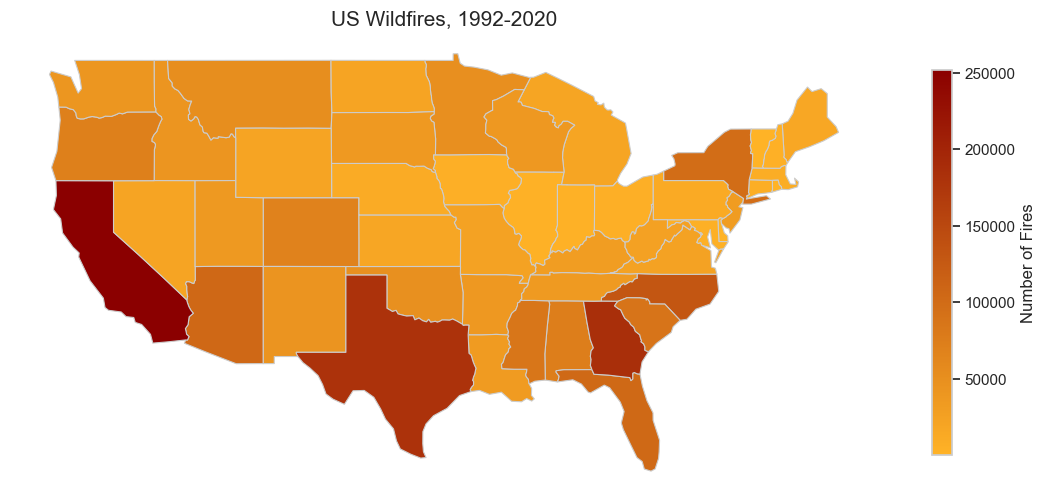

In [20]:
# Add codes for DC and Puerto Rico to the default state lists
state_abb = ["AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"]
state_name = ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]

state_abb.extend(["DC", "PR"])
state_name.extend(["District of Columbia", "Puerto Rico"])

# Map the state abbreviations to state names so we can join with the map data
fires['region'] = fires['STATE'].map(lambda x: state_name[state_abb.index(x.upper())])

# Read the US states map data
us_states = gpd.read_file("C:/Users/leahm/anaconda_3/Library/ne_110m_admin_1_states_provinces.shp")
us_states = us_states[us_states['name'].isin(state_name)]

# Filter out Alaska and Hawaii
excluded_states = ['Alaska', 'Hawaii']
us_states = us_states[~us_states['name'].isin(excluded_states)]

# Merge fires data with US states map data
merged_data = us_states.merge(fires.groupby('region').size().reset_index(name='n'), left_on='name', right_on='region', how='right')

# Create a custom colormap
from matplotlib.colors import LinearSegmentedColormap
colors = [(1.0, 0.7, 0.15), 'darkred']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))  # Adjust the figsize here
merged_data.plot(column='n', cmap=cmap, linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, legend_kwds={'label': 'Number of Fires', 'orientation': 'vertical', 'shrink': 0.5})  # Adjust shrink parameter to make the legend smaller
ax.axis('off')
ax.set_title('US Wildfires, 1992-2020', fontdict={'fontsize': '15', 'fontweight' : '3'})
plt.show()

This map reveals that wildfire occurrence is not evenly distributed across the country. The states with the highest number of recorded fires are California, Texas, and Georgia.

While the prominence of California and Texas is expected due to their large geographic size and diverse climate conditions, Georgia’s appearance among the top states highlights how wildfire activity is also influenced by regional vegetation types, land management practices, and climate variability.

To better understand how wildfire risk may intersect with human exposure, we next examine these states in more detail by comparing wildfire occurrence with population distribution.

### California

In this visualization, we compare wildfire occurrences by county in California alongside county-level population density.

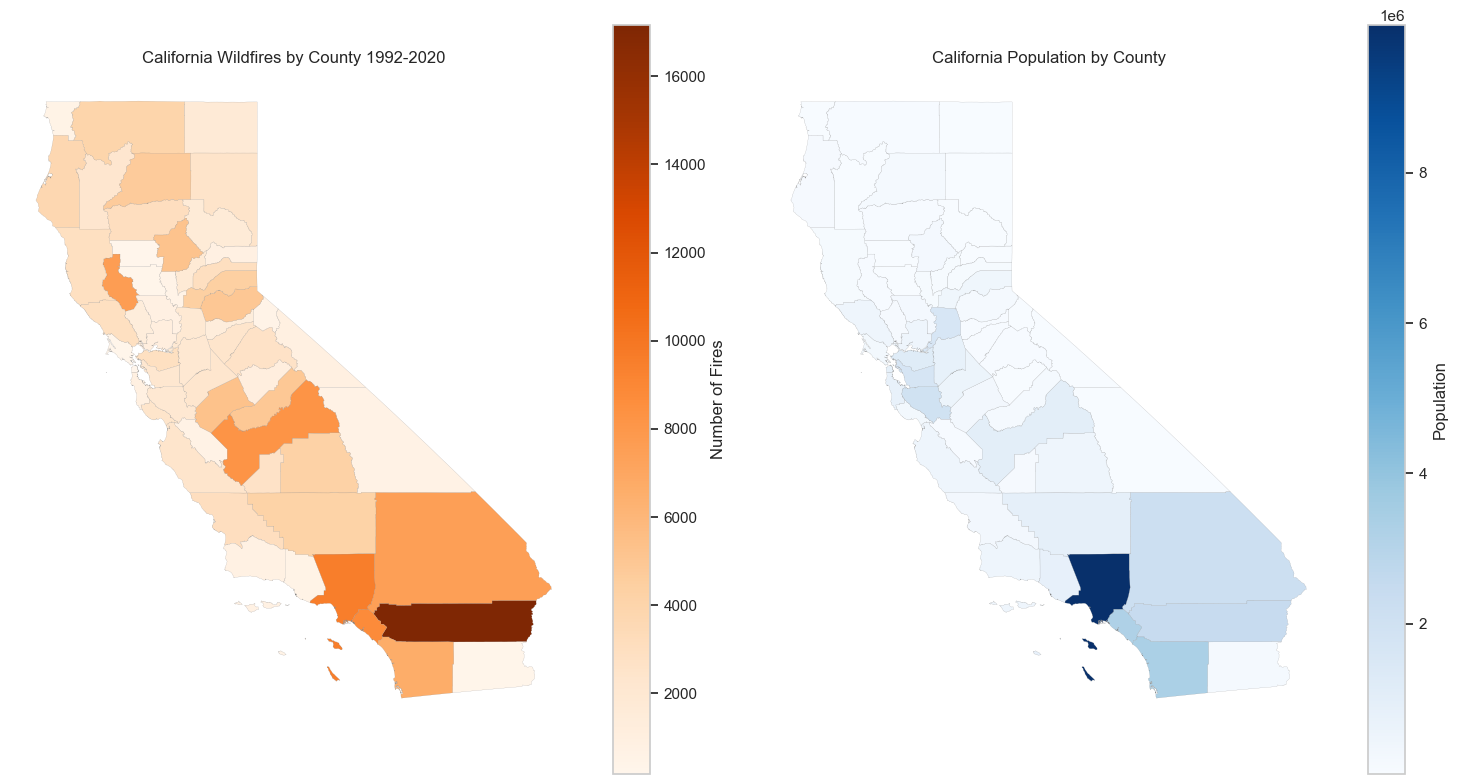

In [23]:
# Load county map data with population included
counties = gpd.read_file("C:/Users/leahm/anaconda_3/Library/USA_Counties.shp")

# Filter counties to only include California
california_counties = counties[counties['STATE_NAME'] == 'California']

# Group fires by county
fires_grouped = fires.groupby('FIPS_NAME')['FIRE_SIZE'].count().reset_index(name='n_fires')

# Merge fire count data with California county map data based on county names
merged_data_fires = california_counties.merge(fires_grouped, left_on='NAME', right_on='FIPS_NAME', how='left')

# Plot wildfires
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot wildfires
merged_data_fires.plot(column='n_fires', cmap='Oranges', linewidth=0.1, ax=axes[0], edgecolor='grey', legend=True, legend_kwds={'label': 'Number of Fires'})
axes[0].set_title('California Wildfires by County 1992-2020')
axes[0].axis('off')

# Plot population
california_counties.plot(column='POPULATION', cmap='Blues', linewidth=0.1, ax=axes[1], edgecolor='grey', legend=True, legend_kwds={'label': 'Population'})
axes[1].set_title('California Population by County')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Wildfire activity appears to be concentrated in several regions across the state, particularly in southern and inland counties. Meanwhile, the highest population densities occur in major metropolitan areas such as Los Angeles.

From a risk perspective, the proximity between high wildfire activity and densely populated areas can significantly increase potential exposure and economic loss. Even when wildfires occur outside major cities, nearby population centers may still be vulnerable to secondary impacts, including smoke exposure, infrastructure disruption, and evacuation events.

However, some northern regions with elevated wildfire activity show relatively lower population density. In these areas, wildfire risk may pose greater ecological impact than direct human exposure, though large fires can still threaten infrastructure and rural communities.

### Texas

Next, we examine the relationship between wildfire activity and population distribution in Texas.

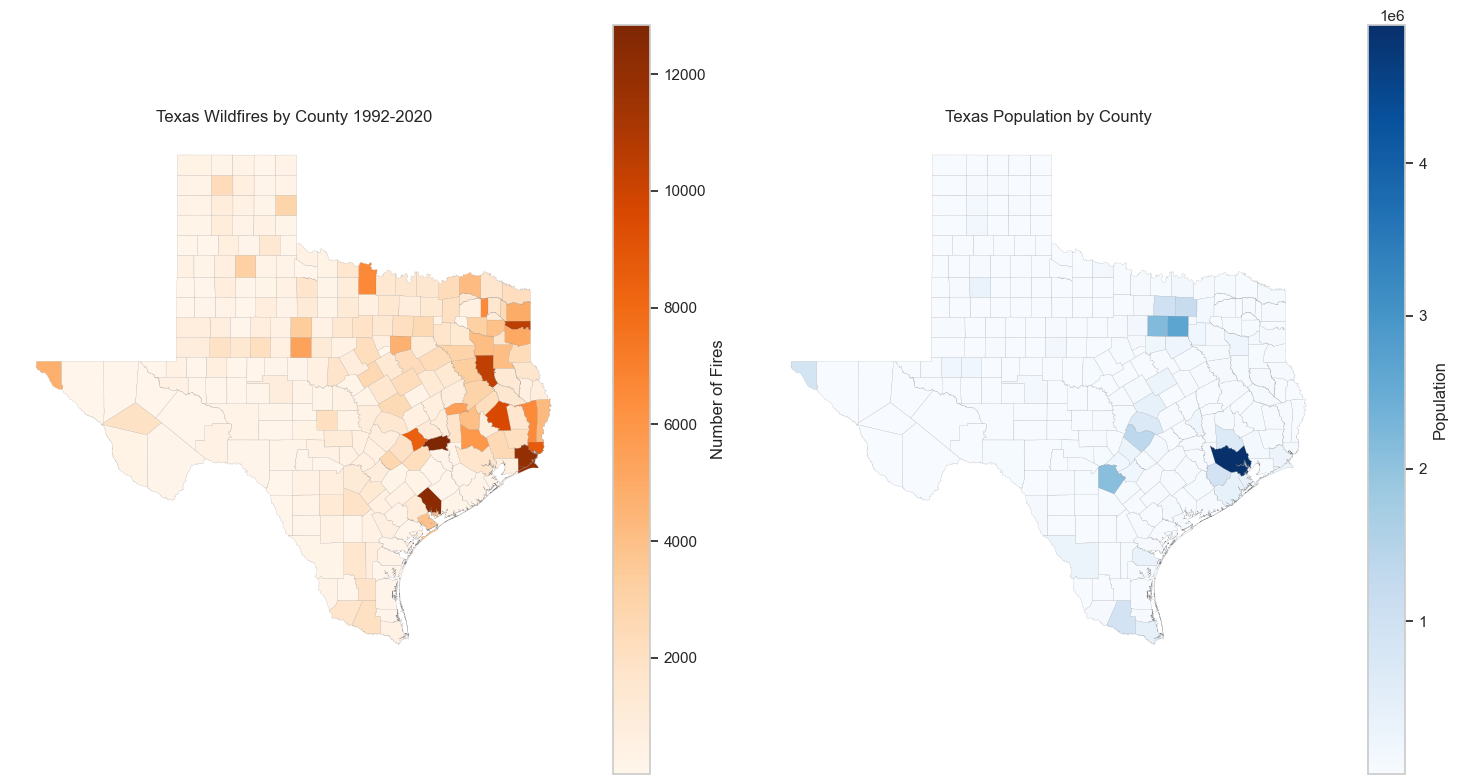

In [26]:
# Load county map data with population included
counties = gpd.read_file("C:/Users/leahm/anaconda_3/Library/USA_Counties.shp")

# Filter counties to only include Texas
Texas_counties = counties[counties['STATE_NAME'] == 'Texas']

# Group fires by county
fires_grouped = fires.groupby('FIPS_NAME')['FIRE_SIZE'].count().reset_index(name='n_fires')

# Merge fire count data with Texas county map data based on county names
merged_data_fires = Texas_counties.merge(fires_grouped, left_on='NAME', right_on='FIPS_NAME', how='left')

# Plot wildfires
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot wildfires
merged_data_fires.plot(column='n_fires', cmap='Oranges', linewidth=0.1, ax=axes[0], edgecolor='grey', legend=True, legend_kwds={'label': 'Number of Fires'})
axes[0].set_title('Texas Wildfires by County 1992-2020')
axes[0].axis('off')

# Plot population
Texas_counties.plot(column='POPULATION', cmap='Blues', linewidth=0.1, ax=axes[1], edgecolor='grey', legend=True, legend_kwds={'label': 'Population'})
axes[1].set_title('Texas Population by County')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Major population centers such as Houston and Dallas show the highest population densities, while wildfire occurrences appear more common in surrounding counties.

This spatial pattern suggests potential wildland–urban interface (WUI) dynamics, where developed areas intersect with fire-prone landscapes. In these regions, wildfire events may pose heightened risk because human development increases both ignition likelihood and potential damage.

Understanding these transitional zones is important for wildfire mitigation planning, including land-use policy, vegetation management, and emergency response planning.

### Georgia

Finally, we examine wildfire activity and population distribution in Georgia.

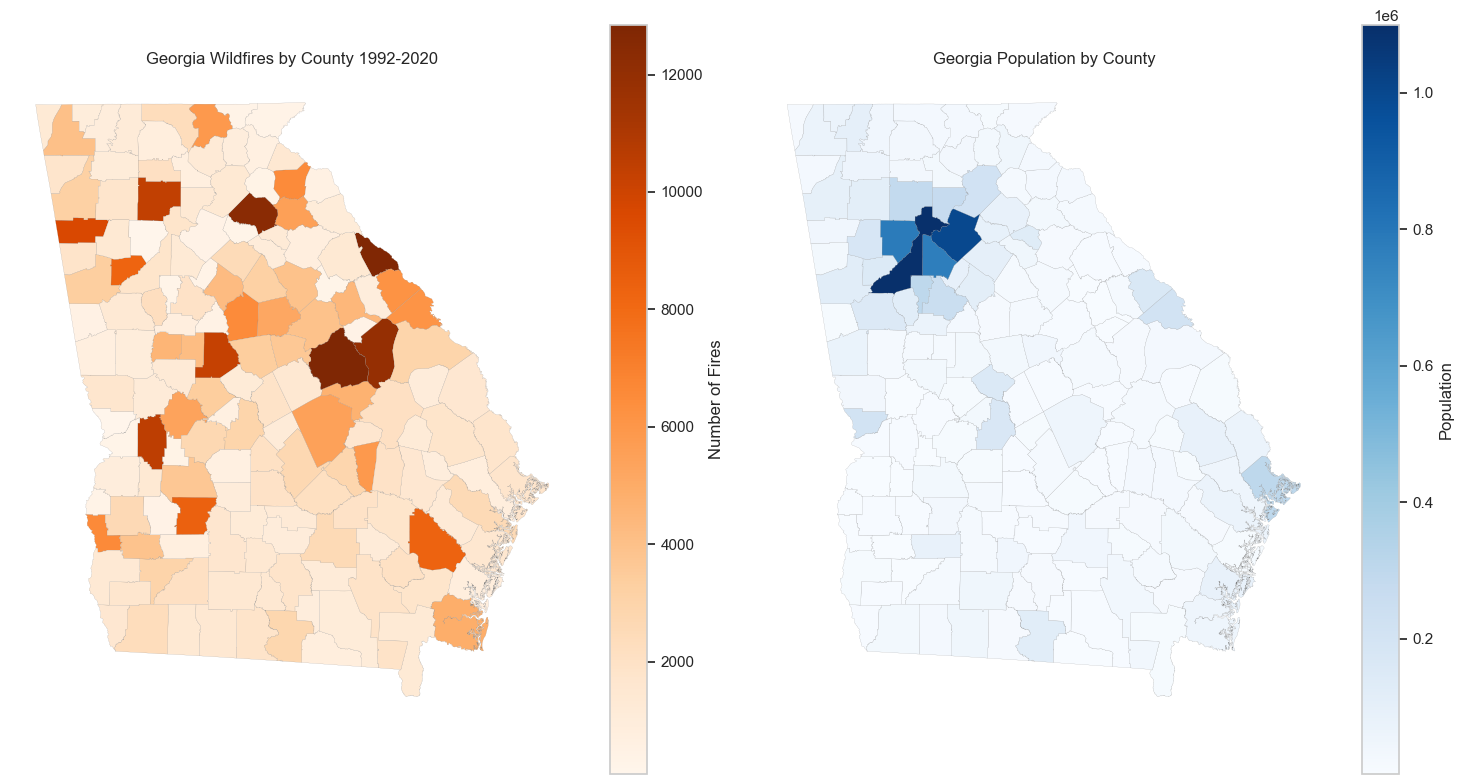

In [29]:
# Load county map data with population included
counties = gpd.read_file("C:/Users/leahm/anaconda_3/Library/USA_Counties.shp")

# Filter counties to only include Georgia
Georgia_counties = counties[counties["STATE_NAME"] == "Georgia"]

# Group fires by county
fires_grouped = fires.groupby('FIPS_NAME')['FIRE_SIZE'].count().reset_index(name='n_fires')

# Merge fire count data with Georgia county map data based on county names
merged_data_fires = Georgia_counties.merge(fires_grouped, left_on='NAME', right_on='FIPS_NAME', how='left')

# Plot wildfires
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot wildfires
merged_data_fires.plot(column='n_fires', cmap='Oranges', linewidth=0.1, ax=axes[0], edgecolor='grey', legend=True, legend_kwds={'label': 'Number of Fires'})
axes[0].set_title('Georgia Wildfires by County 1992-2020')
axes[0].axis('off')

# Plot population
Georgia_counties.plot(column='POPULATION', cmap='Blues', linewidth=0.1, ax=axes[1], edgecolor='grey', legend=True, legend_kwds={'label': 'Population'})
axes[1].set_title('Georgia Population by County')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In Georgia, wildfire incidents appear more broadly distributed across the state, while population density is concentrated around the Atlanta metropolitan area.

Compared to California and Texas, this pattern suggests a weaker spatial correlation between wildfire occurrence and population centers. As a result, wildfire risk in Georgia may involve lower direct exposure for large urban populations, though rural communities and ecosystems may still experience significant impacts.

## Conclusion

Across the three states examined, wildfire activity exhibits different spatial relationships with population density. In some regions, high wildfire activity occurs near densely populated areas, increasing potential risk to human communities. In others, fires occur primarily in less populated landscapes, where ecological impacts may be more significant than direct human exposure.

These differences highlight the importance of regional wildfire risk assessment, as the drivers of wildfire hazard, exposure, and vulnerability vary considerably across geographic contexts.